# Platform Comparison: $T_1/t_\mathrm{gate}$ as a Fidelity Predictor

**Q1 — Decay vs. Circuit Depth**: How does qubit decay suppress Grover's success probability as a function of circuit depth, and does the suppression rate scale with $N$?

**Q2 — Fidelity Degradation vs. N**: How does noise-induced fidelity loss at $k_\mathrm{opt}$ scale with search space size $N$ across platforms?

**Q3 — $T_1/t_\mathrm{gate}$ as a Fidelity Predictor**: Can the $T_1/t_\mathrm{gate}$ ratio alone rank the four platforms by Grover search fidelity?

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

thresholds = pd.read_csv('../data/results/thresholds.csv')
FIGURES_DIR = '../results/figures'

platforms = thresholds['platform'].unique()
N_values = sorted(thresholds['N'].unique())
colors_p = {p: c for p, c in zip(platforms, plt.cm.tab10(np.linspace(0, 0.8, len(platforms))))}
display(thresholds[['platform', 'N', 'best_success', 'fidelity_ratio', 'ratio']])

,platform,N,best_success,fidelity_ratio,ratio
0,IBM Quantum (Eagle),4,0.997004,0.997004,2000.000000
1,IBM Quantum (Eagle),8,0.938249,0.992528,2000.000000
2,IBM Quantum (Eagle),16,0.947954,0.986098,2000.000000
3,IBM Quantum (Eagle),32,0.976952,0.977751,2000.000000
4,IBM Quantum (Eagle),64,0.958467,0.961751,2000.000000
5,IBM Quantum (Eagle),128,0.938108,0.942236,2000.000000
6,IBM Quantum (Eagle),256,0.904789,0.904837,2000.000000
7,IBM Quantum (Eagle),512,0.853805,0.854277,2000.000000
8,IBM Quantum (Eagle),1024,0.774499,0.774916,2000.000000
9,IBM Quantum (Eagle),2048,0.676716,0.676718,2000.000000


## Q2 — Fidelity Degradation vs. $N$

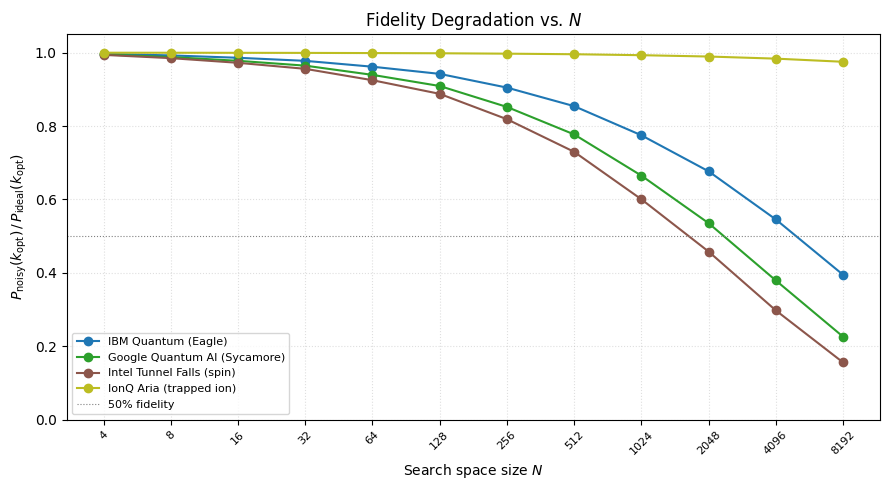

In [5]:
fig, ax = plt.subplots(figsize=(9, 5))
for platform in platforms:
    sub = thresholds[thresholds['platform'] == platform].sort_values('N')
    ax.plot(sub['N'], sub['fidelity_ratio'], marker='o', label=platform, color=colors_p[platform])

ax.set_xlabel('Search space size $N$')
ax.set_ylabel(r'$P_\mathrm{noisy}(k_\mathrm{opt})\,/\,P_\mathrm{ideal}(k_\mathrm{opt})$')
ax.set_title('Fidelity Degradation vs. $N$')
ax.set_xscale('log', base=2)
ax.set_xticks(N_values)
ax.set_xticklabels([str(N) for N in N_values], rotation=45, fontsize=8)
ax.set_ylim(0, 1.05)
ax.axhline(0.5, color='gray', linestyle=':', linewidth=0.8, label='50% fidelity')
ax.legend(fontsize=8)
ax.grid(True, which='both', linestyle=':', alpha=0.4)
plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}/fidelity_ratio_vs_N.png', dpi=150)
plt.show()

## Q3 — Scatter: $T_1/t_\mathrm{gate}$ vs. Peak Success at $k_\mathrm{opt}$

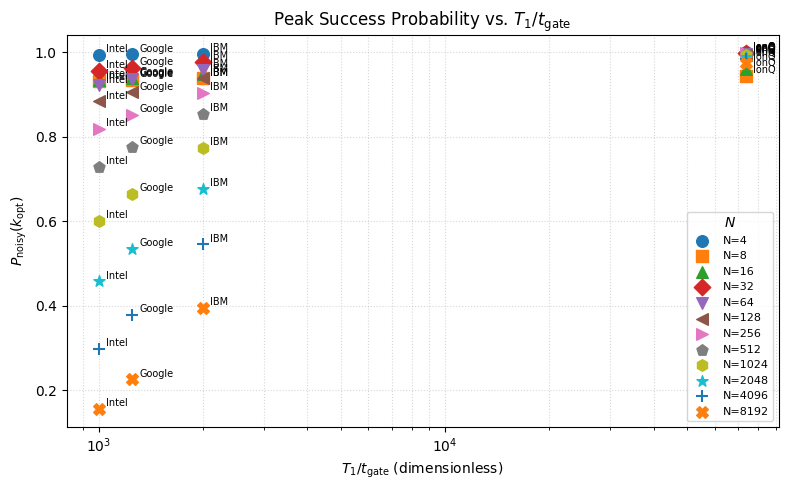

In [6]:
markers = ['o', 's', '^', 'D', 'v', '<', '>', 'p', 'h', '*', '+', 'X']

fig, ax = plt.subplots(figsize=(8, 5))
for N, marker in zip(N_values, markers[:len(N_values)]):
    sub = thresholds[thresholds['N'] == N]
    ax.scatter(sub['ratio'], sub['best_success'], marker=marker, s=70, label=f'N={N}', zorder=3)
    for _, row in sub.iterrows():
        ax.annotate(
            row['platform'].split()[0],
            (row['ratio'], row['best_success']),
            textcoords='offset points', xytext=(5, 2), fontsize=7,
        )

ax.set_xscale('log')
ax.set_xlabel('$T_1 / t_\\mathrm{gate}$ (dimensionless)')
ax.set_ylabel('$P_\\mathrm{noisy}(k_\\mathrm{opt})$')
ax.set_title('Peak Success Probability vs. $T_1/t_\\mathrm{gate}$')
ax.legend(title='$N$', fontsize=8)
ax.grid(True, which='both', linestyle=':', alpha=0.5)
plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}/ratio_vs_best_success.png', dpi=150)
plt.show()

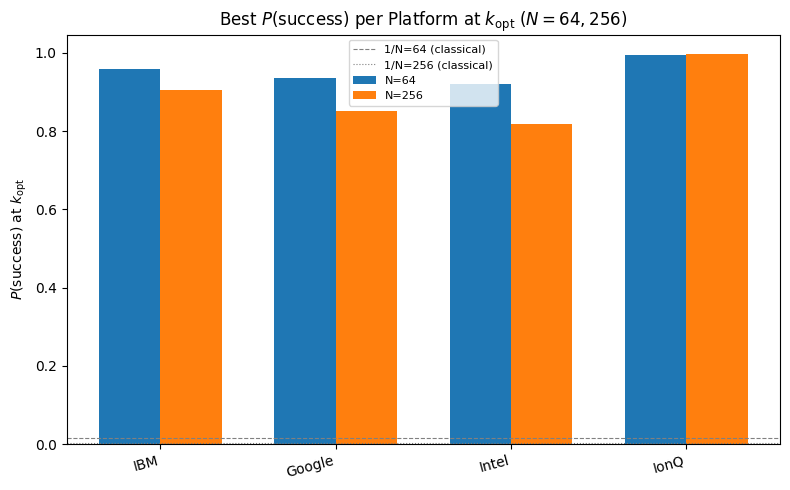

In [7]:
N_bar = [64, 256]
x = np.arange(len(platforms))
width = 0.35

fig, ax = plt.subplots(figsize=(8, 5))
for i, N in enumerate(N_bar):
    sub = thresholds[thresholds['N'] == N].set_index('platform')
    vals = [sub.loc[p, 'best_success'] if p in sub.index else 0.0 for p in platforms]
    ax.bar(x + i * width, vals, width, label=f'N={N}')

ax.axhline(1 / 64,  color='gray', linestyle='--', linewidth=0.8, label='1/N=64 (classical)')
ax.axhline(1 / 256, color='gray', linestyle=':',  linewidth=0.8, label='1/N=256 (classical)')
ax.set_xticks(x + width / 2)
ax.set_xticklabels([p.split()[0] for p in platforms], rotation=15, ha='right')
ax.set_ylabel('$P(\mathrm{success})$ at $k_\mathrm{opt}$')
ax.set_title('Best $P(\mathrm{success})$ per Platform at $k_\mathrm{opt}$ ($N=64, 256$)')
ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}/best_success_bar.png', dpi=150)
plt.show()

## Q3 — Limitations of $T_1/t_\mathrm{gate}$ as a Fidelity Predictor

$T_1/t_\mathrm{gate}$ captures relaxation during idle time. It misses:

- **Gate fidelity**: IonQ two-qubit gates ~99.4%; IBM/Google ~99.5–99.6%. Per-gate coherent error is comparable across platforms; $T_1$ alone does not predict it.
- **Clock speed**: IBM gate ~50 ns; IonQ gate ~135,000 ns — a 2700x throughput gap. For large-scale workloads (e.g., VQE parameter sweeps), wall-clock time favors superconducting by orders of magnitude.
- **Connectivity**: IonQ has all-to-all connectivity. IBM heavy-hex requires SWAP routing (3 CNOTs per logical SWAP), so a depth-$d$ logical circuit can become depth $3d+$ physically. This Grover diffuser assumes all-to-all; real superconducting runs pay a SWAP overhead not reflected here.
- **Scalability**: IBM Condor exceeds 1,000 qubits; IonQ Aria is 25 qubits. Trapped-ion chains are difficult to extend; superconducting qubits are lithographically printed.
- **Verdict**: $T_1/t_\mathrm{gate}$ predicts fidelity when relaxation dominates, deep circuits, large $N$, long idle times. For shallow circuits or throughput-limited workloads, gate fidelity, connectivity overhead, and clock speed dominate.